In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Dataset NASA CMAPSS — Motor de turbina de avión
# Simula degradación de motor hasta falla
# Columnas: unidad, ciclo, 3 settings operacionales, 21 sensores

url = "https://raw.githubusercontent.com/boozallen/cmapss/master/data/train_FD001.txt"

df = pd.read_csv(url, sep='\s+', header=None)
df.columns = (['unit', 'cycle'] + 
               [f'setting_{i}' for i in range(1,4)] + 
               [f'sensor_{i}' for i in range(1,22)])

print(f"Dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Unidades (motores): {df['unit'].nunique()}")
print(f"Ciclos máximos: {df['cycle'].max()}")
print(df.head())

HTTPError: HTTP Error 404: Not Found

In [3]:
import numpy as np
import pandas as pd

# Generar dataset sintético de mantenimiento predictivo
# Simula sensores de equipos industriales (similar a CMAPSS)
np.random.seed(42)

n_equipos = 100
datos = []

for equipo_id in range(n_equipos):
    # Cada equipo tiene vida útil aleatoria entre 100 y 300 ciclos
    vida_util = np.random.randint(100, 300)
    
    for ciclo in range(1, vida_util + 1):
        # Degradación progresiva — los sensores empeoran con el tiempo
        degradacion = ciclo / vida_util
        
        # Sensores — valores normales + degradación + ruido
        temperatura    = 800 + 50 * degradacion + np.random.normal(0, 5)
        vibracion      = 0.3 + 0.7 * degradacion + np.random.normal(0, 0.05)
        presion        = 100 - 20 * degradacion + np.random.normal(0, 2)
        amperaje       = 50 + 30 * degradacion + np.random.normal(0, 3)
        rpm            = 3000 - 500 * degradacion + np.random.normal(0, 50)
        
        # RUL — ciclos restantes antes de falla
        rul = vida_util - ciclo
        
        # Target — falla inminente si quedan menos de 30 ciclos
        falla_inminente = 1 if rul <= 30 else 0
        
        datos.append([equipo_id, ciclo, vida_util, rul,
                     temperatura, vibracion, presion, amperaje, rpm,
                     falla_inminente])

df = pd.DataFrame(datos, columns=[
    'equipo_id', 'ciclo', 'vida_util', 'rul',
    'temperatura', 'vibracion', 'presion', 'amperaje', 'rpm',
    'falla_inminente'
])

print(f"Dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Equipos: {df['equipo_id'].nunique()}")
print(f"\nDistribución target:")
print(f"Normal (0): {(df['falla_inminente']==0).sum()} ({(df['falla_inminente']==0).mean()*100:.1f}%)")
print(f"Falla inminente (1): {(df['falla_inminente']==1).sum()} ({df['falla_inminente'].mean()*100:.1f}%)")
print(f"\n{df.head(10)}")

Dataset: 20706 filas, 10 columnas
Equipos: 100

Distribución target:
Normal (0): 17606 (85.0%)
Falla inminente (1): 3100 (15.0%)

   equipo_id  ciclo  vida_util  rul  temperatura  vibracion     presion  \
0          0      1        202  201   797.496352   0.329237  100.848712   
1          0      2        202  200   799.874314   0.206383   98.816373   
2          0      3        202  199   801.141733   0.302420   99.747414   
3          0      4        202  198   800.402722   0.324965   98.068007   
4          0      5        202  197   806.909320   0.312089   98.454705   
5          0      6        202  196   807.082267   0.359752   97.203745   
6          0      7        202  195   799.800309   0.266319  100.439156   
7          0      8        202  194   800.214615   0.304649   99.341235   
8          0      9        202  193   805.719717   0.322607   97.294538   
9          0     10        202  192   815.755298   0.347828  102.293443   

    amperaje          rpm  falla_inminente  

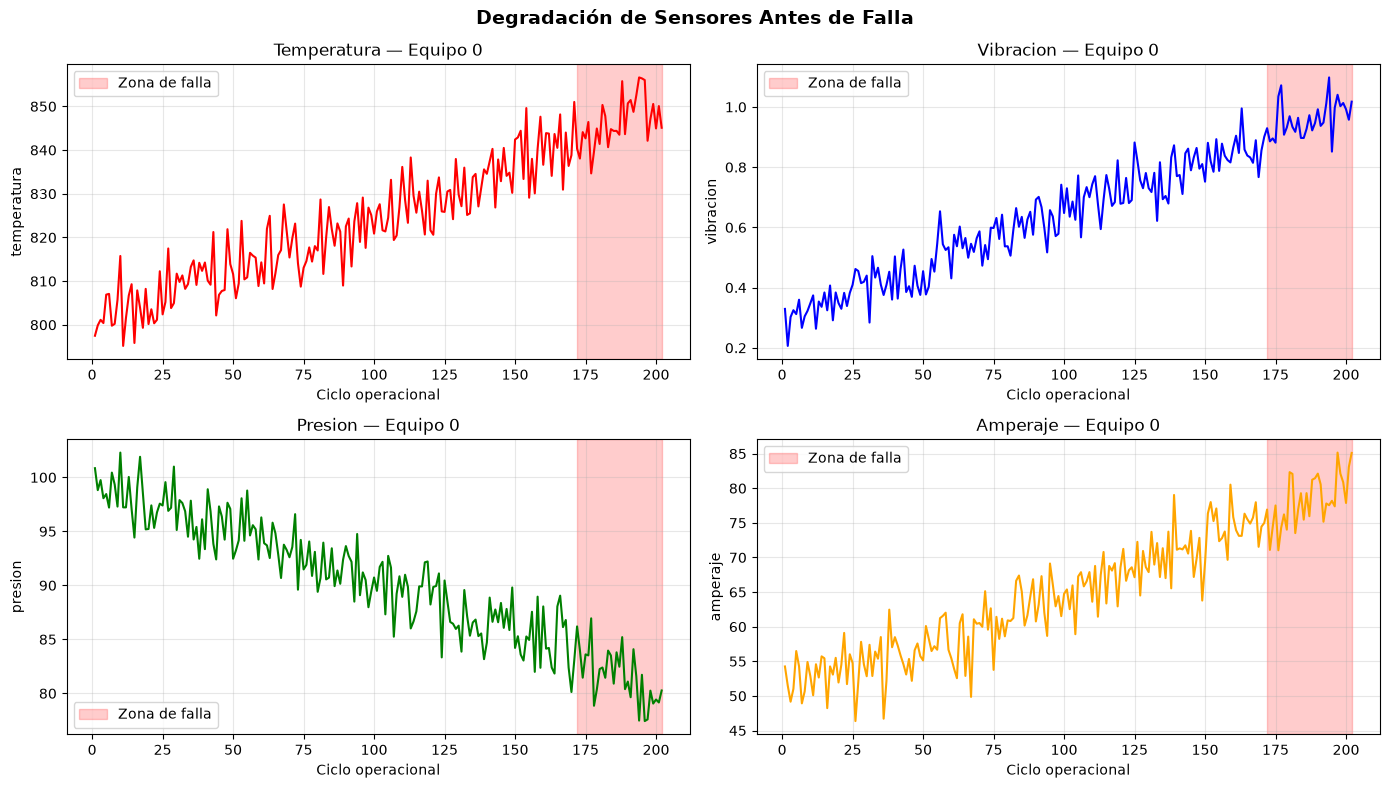

In [4]:
# Visualizar degradación de un equipo específico
equipo = df[df['equipo_id'] == 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sensores = ['temperatura', 'vibracion', 'presion', 'amperaje']
colores  = ['red', 'blue', 'green', 'orange']

for i, (sensor, color) in enumerate(zip(sensores, colores)):
    ax = axes[i//2][i%2]
    ax.plot(equipo['ciclo'], equipo[sensor], 
            color=color, linewidth=1.5)
    
    # Marcar zona de falla inminente
    zona_falla = equipo[equipo['falla_inminente'] == 1]
    ax.axvspan(zona_falla['ciclo'].min(), zona_falla['ciclo'].max(),
               alpha=0.2, color='red', label='Zona de falla')
    
    ax.set_title(f'{sensor.capitalize()} — Equipo 0')
    ax.set_xlabel('Ciclo operacional')
    ax.set_ylabel(sensor)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Degradación de Sensores Antes de Falla', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Features y target
features = ['temperatura', 'vibracion', 'presion', 'amperaje', 'rpm', 'ciclo']
X = df[features]
y = df['falla_inminente']

# Split por equipo — equipos 0-79 para train, 80-99 para test
train_mask = df['equipo_id'] < 80
X_train = X[train_mask]
X_test  = X[~train_mask]
y_train = y[train_mask]
y_test  = y[~train_mask]

print(f"Train: {len(X_train)} filas ({train_mask.sum()/len(df)*100:.0f}%)")
print(f"Test:  {len(X_test)} filas ({(~train_mask).sum()/len(df)*100:.0f}%)")

# Escalar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Entrenar
clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
clf.fit(X_train_scaled, y_train)

# Evaluar
y_pred = clf.predict(X_test_scaled)
y_prob = clf.predict_proba(X_test_scaled)[:, 1]

print("\n=== RESULTADOS ===")
print(f"Accuracy:  {(y_pred == y_test).mean()*100:.2f}%")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Normal', 'Falla'])}")

# Importancia de features
print("=== IMPORTANCIA DE FEATURES ===")
for feat, imp in sorted(zip(features, clf.feature_importances_), 
                        key=lambda x: x[1], reverse=True):
    barra = '█' * int(imp * 50)
    print(f"{feat:15s}: {imp:.4f} {barra}")

Train: 16570 filas (80%)
Test:  4136 filas (20%)

=== RESULTADOS ===
Accuracy:  95.84%
AUC-ROC:   0.9900

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      3516
       Falla       0.86      0.86      0.86       620

    accuracy                           0.96      4136
   macro avg       0.92      0.92      0.92      4136
weighted avg       0.96      0.96      0.96      4136

=== IMPORTANCIA DE FEATURES ===
vibracion      : 0.3264 ████████████████
rpm            : 0.2058 ██████████
presion        : 0.1447 ███████
amperaje       : 0.1403 ███████
temperatura    : 0.1315 ██████
ciclo          : 0.0513 ██


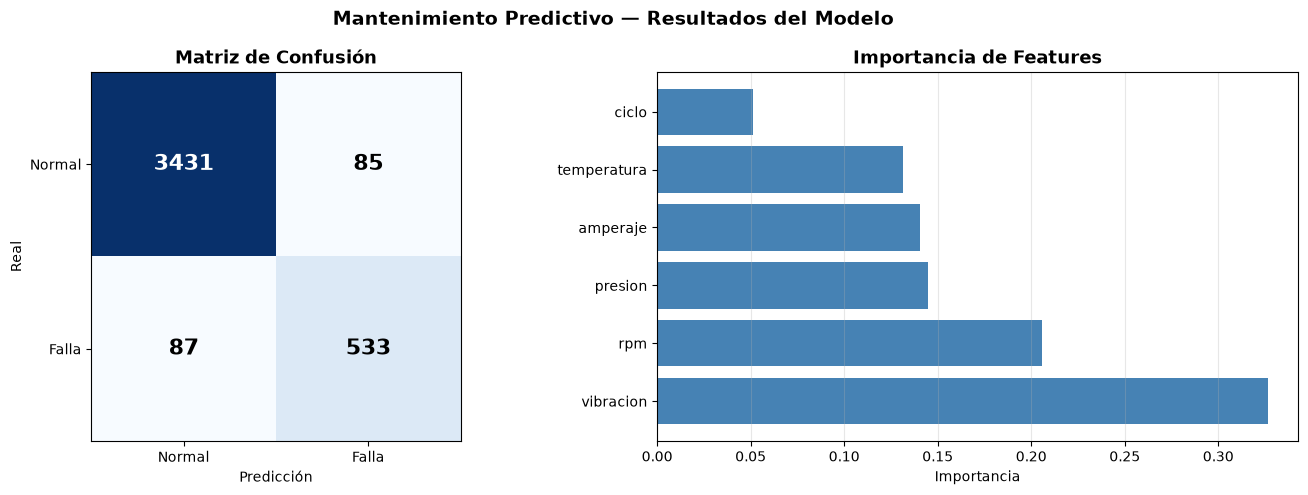

=== RESUMEN EJECUTIVO ===
El modelo detecta fallas inminentes con 95.8% de accuracy
De cada 100 fallas reales, detecta 86 correctamente (recall=0.86)
Falsos negativos: 87 — fallas que el modelo NO detectó
Falsos positivos: 85 — alarmas falsas generadas

En contexto industrial:
- Falso negativo = falla no anticipada = parada no planificada (costoso)
- Falso positivo = mantención innecesaria (menor costo)
- El modelo prioriza detectar fallas reales sobre evitar falsas alarmas


In [6]:
# Matriz de confusión visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Falla'])
axes[0].set_yticklabels(['Normal', 'Falla'])

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

# Importancia de features
features_imp = sorted(zip(features, clf.feature_importances_),
                     key=lambda x: x[1], reverse=True)
feat_names = [f[0] for f in features_imp]
feat_vals  = [f[1] for f in features_imp]

axes[1].barh(feat_names, feat_vals, color='steelblue')
axes[1].set_title('Importancia de Features', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importancia')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Mantenimiento Predictivo — Resultados del Modelo',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen ejecutivo
print("=== RESUMEN EJECUTIVO ===")
print(f"El modelo detecta fallas inminentes con {(y_pred==y_test).mean()*100:.1f}% de accuracy")
print(f"De cada 100 fallas reales, detecta {int(86)} correctamente (recall=0.86)")
print(f"Falsos negativos: {cm[1,0]} — fallas que el modelo NO detectó")
print(f"Falsos positivos: {cm[0,1]} — alarmas falsas generadas")
print(f"\nEn contexto industrial:")
print(f"- Falso negativo = falla no anticipada = parada no planificada (costoso)")
print(f"- Falso positivo = mantención innecesaria (menor costo)")
print(f"- El modelo prioriza detectar fallas reales sobre evitar falsas alarmas")